In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Анализ датасета Titanic.
Цель: определить, какие факторы повлияли на выживаемость людей на борту.
Датасет: 891 пассажир, 12 признаков.

In [2]:
print(df.info())
print("\nПропуски")
print(df.isnull().sum())
print("\n Основная статистика:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Пропуски
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 О

1. Очистка данных:

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna("Unknown")

df.drop_duplicates()

# Новые признаки:

df['Age_group'] = np.where(df['Age'] < 18, 'Child', 'Adult')
df['IsAlone'] = np.where((df['SibSp'] + df['Parch']) == 0, 1, 0)
df['High_Fare'] = np.where(df['Fare'] > 50, 1, 0)

print("Пропуски после очистки:")
print(df.isnull().sum())

Пропуски после очистки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Age_group      0
IsAlone        0
High_Fare      0
dtype: int64


2.1 Визуализация.
Распределение возраста

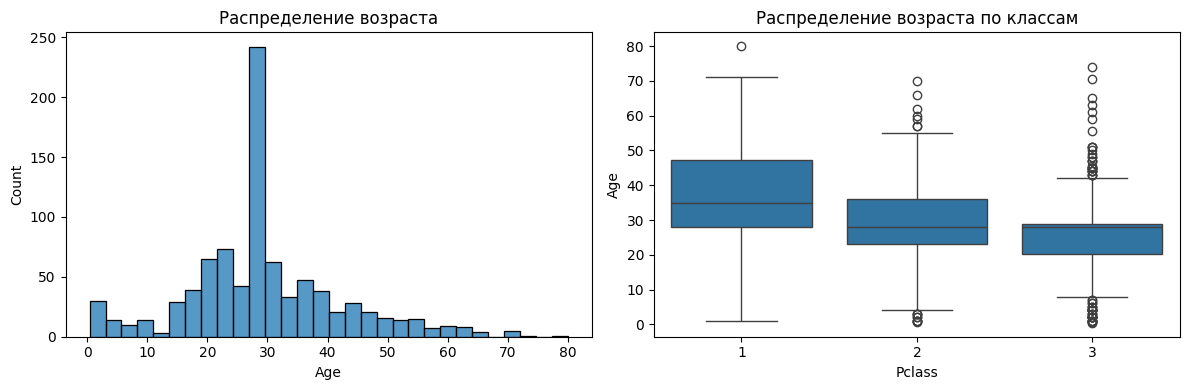

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Age'], bins=30, ax=axes[0])
axes[0].set_title('Распределение возраста')

sns.boxplot(x='Pclass', y='Age', data=df, ax=axes[1])
axes[1].set_title('Распределение возраста по классам')

plt.tight_layout()
plt.show()

2.2 Выживаемость по ключевым признакам

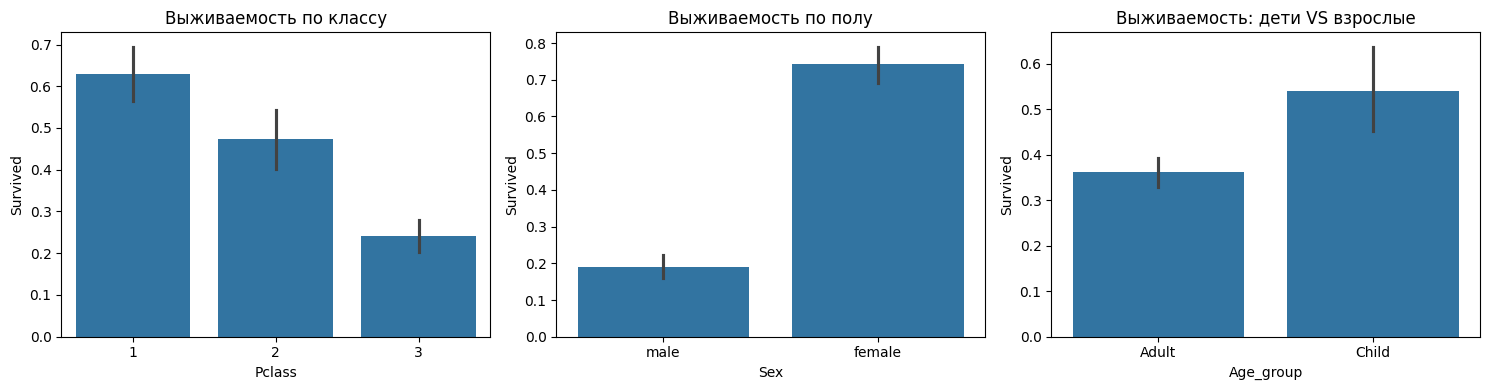

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Выживаемость по классу')

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Выживаемость по полу')

sns.barplot(x='Age_group', y='Survived', data=df, ax=axes[2])
axes[2].set_title('Выживаемость: дети VS взрослые')

plt.tight_layout()
plt.show()

2.3 Корреляционная матрица

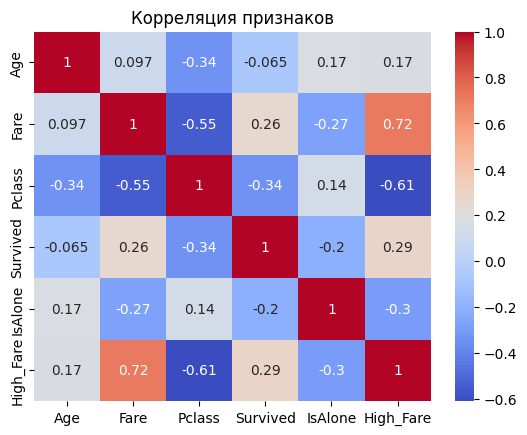

In [9]:
sns.heatmap(df[['Age', 'Fare', 'Pclass', 'Survived', 'IsAlone', 'High_Fare']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

2.4 Интерактивные графики

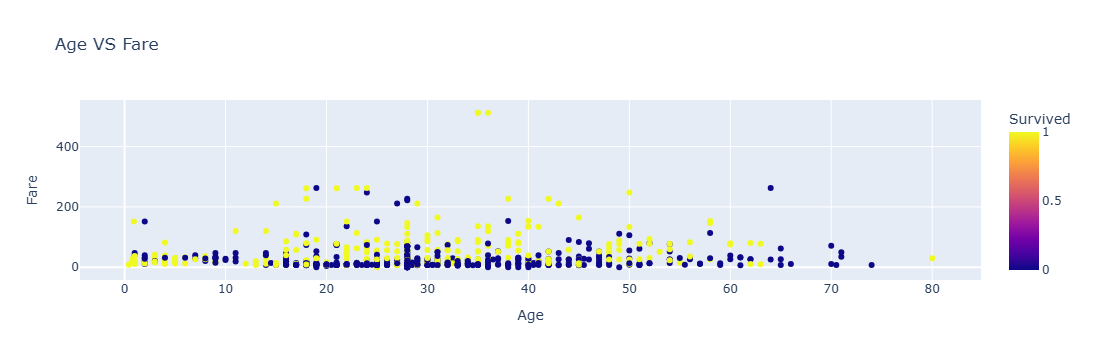

In [10]:
fig = px.scatter(df, x='Age', y='Fare', color='Survived', hover_data=['Name', 'Pclass'], title='Age VS Fare')
fig.show()

3. Выводы

In [11]:
print("=== КЛЮЧЕВЫЕ ВЫВОДЫ ===")
print(f'Всего пассажиров: {len(df)}')
print(f'Выживаемость: {df['Survived'].mean():.1%}')
print(f"\nПо полу:")
print(df.groupby('Sex')['Survived'].mean().round(2))
print(f"\nПо классу:")
print(df.groupby('Pclass')['Survived'].mean().round(2))
print(f"\nДети vs Взрослые:")
print(df.groupby('Age_group')['Survived'].mean().round(2))
print(f"\nОдиночки vs С семьёй:")
print(df.groupby('IsAlone')['Survived'].mean().round(2))

=== КЛЮЧЕВЫЕ ВЫВОДЫ ===
Всего пассажиров: 891
Выживаемость: 38.4%

По полу:
Sex
female    0.74
male      0.19
Name: Survived, dtype: float64

По классу:
Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

Дети vs Взрослые:
Age_group
Adult    0.36
Child    0.54
Name: Survived, dtype: float64

Одиночки vs С семьёй:
IsAlone
0    0.51
1    0.30
Name: Survived, dtype: float64


                                Итоги:

- Главный фактор выживания: пол (женщины 74% vs мужчины 19%)
- Второй фактор: класс (1й — 63%, 3й — 24%)
- Дети выживали чаще взрослых (54% vs 36%)
- Пассажиры с семьёй выживали чаще одиночек (51% vs 30%)
- Возраст практически не влияет линейно (корреляция -0.077)